# CHOMP optimizer — tests & comparison with the WarmStartPlanner

CHOMP is a classical, learning-free trajectory optimizer. It minimizes collision + joint-limits +
smoothness via a covariant gradient update with fixed start/goal, and can be warm-started from a
model trajectory.

**Two independent weight sets** (see `chomp.py`):

* **Optimization hyperparameters** (`eps`, `w_coll`, `w_smooth`, ...) drive the descent. Defaults are
  tuned for *single-trajectory* CHOMP. The Bigboy *training* weights (wide `eps=0.8` + strong
  smoothness) are great for training a network but make single-trajectory CHOMP straighten wide
  detours back into obstacles — so they are deliberately **not** the optimizer defaults.
* **Evaluation weights** (`eval_*`) define the **comparison metric** and default to the **Bigboy
  training objective**, so model and CHOMP are judged on exactly the loss the model was trained on.
  `evaluate_trajectory` always uses these, plus weight-independent geometric feasibility
  (`collision_free`, `n_collision_pts`, `min_clearance`) using the sphere *surface* clearance —
  the cleanest comparison signal.

**Headline finding:** CHOMP from a straight-line init almost always gets stuck in a local minimum on
this problem class. The learned model is far faster and more often collision-free, and
**model → CHOMP refinement is the best of both**.

In [30]:
# ---- Setup ----
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.robot import RobotInfo
from simplearm.geom import Obstacles
from simplearm.viz import RobotViewer

from chomp import CHOMPOptimizer
from evaluation import TrajectoryEvaluator
import models
from visualization import save_viewer_as_gif

DEVICE = "cpu"
GRID_LENGTH = 2.5
torch.manual_seed(0)
np.random.seed(0)

## 1. Load the Bigboy dataset & trained model

`CHOMPOptimizer.from_metadata` builds robot / joint-limits / grid straight from the dataset metadata
(same setup as `training.train`).

In [31]:
DATASET_PATH = "data/good_dataset_test.pt"
MODEL_PATH   = "models/warm_start_planner.pt"

ds   = torch.load(DATASET_PATH, weights_only=False)
meta = ds["metadata"]

chomp = CHOMPOptimizer.from_metadata(meta, T=50, device=DEVICE)
print("optimizer HP :", dict(eps=chomp.eps, w_coll=chomp.w_coll, w_smooth=chomp.w_smooth,
                             agg=chomp.collision_agg, eta=chomp.eta))
print("eval metric  :", dict(eps=chomp.eval_eps, w_coll=chomp.eval_w_coll,
                             w_smooth=chomp.eval_w_smooth, agg=chomp.eval_collision_agg))

# Standalone evaluator (independent of the optimizer) — same Bigboy comparison metric.
ev    = TrajectoryEvaluator.from_metadata(meta, device=DEVICE)
robot = chomp.robot

model = models.WarmStartPlanner(dof=meta["dof"], T=50, C=10, linklengths=meta["linklengths"]).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print("\nLoaded model:", MODEL_PATH, "| dataset N =", meta["N"])

optimizer HP : {'eps': 0.2, 'w_coll': 5.0, 'w_smooth': 0.03, 'agg': 'sum', 'eta': 1500.0}
eval metric  : {'eps': 0.8, 'w_coll': 50.0, 'w_smooth': 1.0, 'agg': 'max'}

Loaded model: models/warm_start_planner.pt | dataset N = 750


## 2. One sample: model vs. CHOMP-from-scratch vs. model→CHOMP

Pick a sample where the model output still collides. We expect: CHOMP-from-scratch reduces
collisions a lot but stays stuck; model→CHOMP clears it.

In [32]:
# Find a sample where the model output collides but model->CHOMP fixes it
# (the compelling before/after). Fall back to the first colliding sample.
i, fallback = None, None
for k in range(min(40, meta["N"])):
    sk, qk, gk = ds["sdf"][k:k+1], ds["q_start"][k:k+1], ds["q_goal"][k:k+1]
    with torch.no_grad():
        wp_k = model(qk, gk, sk)
    if ev.evaluate(model.trajectory(wp_k), sk)["collision_free"]:
        continue
    if fallback is None:
        fallback = k
    tr_k = chomp.optimize(sk, qk, gk, init_waypoints=wp_k, max_iters=300)
    if ev.evaluate(tr_k, sk)["collision_free"]:
        i = k; break
i = i if i is not None else (fallback if fallback is not None else 0)
print(f"Using sample {i} (model output collides)")

sdf_i = ds["sdf"][i]
qs_i  = ds["q_start"][i:i+1]
qg_i  = ds["q_goal"][i:i+1]
n_obs = ds["n_obstacles"][i].item()
obs_i = ds["obstacles"][i, :n_obs]
obstacles_i = Obstacles(x=obs_i[:, 0].numpy(), y=obs_i[:, 1].numpy(), r=obs_i[:, 2].numpy())

with torch.no_grad():
    wp_i       = model(qs_i, qg_i, sdf_i.unsqueeze(0))
    traj_model = model.trajectory(wp_i)

# Optimize until convergence (collision-free OR cost plateau), capped at max_iters.
traj_scratch, hist = chomp.optimize(sdf_i, qs_i, qg_i, max_iters=500, return_history=True)
traj_refined       = chomp.optimize(sdf_i, qs_i, qg_i, init_waypoints=wp_i, max_iters=500)
print(f"CHOMP-from-scratch ran {len(hist)} iterations until convergence\n")

import pandas as pd
rows = {name: ev.evaluate(tr, sdf_i)
        for name, tr in [("model", traj_model), ("CHOMP scratch", traj_scratch),
                         ("model+CHOMP", traj_refined)]}
pd.DataFrame(rows).T[["collision_free", "n_collision_pts", "min_clearance",
                      "smooth", "joint_path_length", "ee_path_length", "total"]]

Using sample 2 (model output collides)
CHOMP-from-scratch ran 96 iterations until convergence



,collision_free,n_collision_pts,min_clearance,smooth,joint_path_length,ee_path_length,total
model,False,1,-0.025634,2.72013,10.887656,2.529346,43.346839
CHOMP scratch,False,9,-0.143868,0.682377,5.900989,5.25713,41.012997
model+CHOMP,True,0,0.008352,2.892513,11.289101,2.507576,46.390407


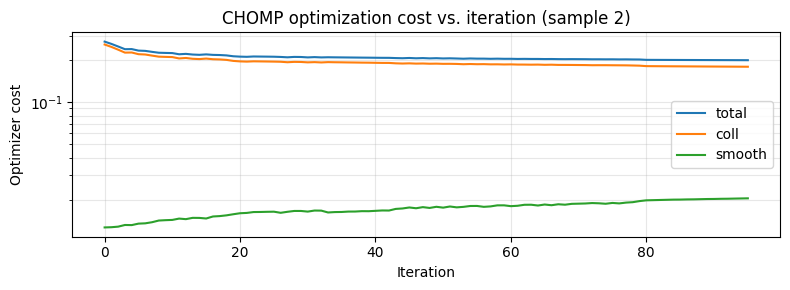

In [33]:
# ---- CHOMP-from-scratch optimization cost vs. iteration ----
fig, ax = plt.subplots(figsize=(8, 3))
for key in ["total", "coll", "smooth"]:
    ax.plot([h[key] for h in hist], label=key)
ax.set_xlabel("Iteration"); ax.set_ylabel("Optimizer cost"); ax.set_yscale("log")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
ax.set_title(f"CHOMP optimization cost vs. iteration (sample {i})")
plt.tight_layout(); plt.show()

In [34]:
# ---- Before / after visualization (model vs. model+CHOMP) ----
for label, tr in [("model", traj_model), ("model + CHOMP", traj_refined)]:
    print(label)
    viz = RobotViewer(tr.squeeze(0).cpu().numpy(), robot, obstacles=obstacles_i, animate=True)
    viz.plot()

# Save the refined trajectory as a GIF
viz = RobotViewer(traj_refined.squeeze(0).cpu().numpy(), robot, obstacles=obstacles_i, animate=True)
viz.plot()
save_viewer_as_gif(viz, f"resources/model_chomp_sample_{i}.gif", duration_ms=60)

model
⠴ Plotting robot... (0:00:01.01) 

model + CHOMP                    
⠼ Plotting robot... (0:00:00.94) 

⠼ Plotting robot... (0:00:00.93) 

GIF gespeichert: resources/model_chomp_sample_2.gif


## 3. Speed & final-result comparison over many samples

The main comparison: collision-free rate, **iterations-to-convergence**, and wall-clock speed for
**model**, **CHOMP from scratch**, and **model→CHOMP refinement**, all judged on the same Bigboy
evaluation metric. CHOMP runs until convergence (collision-free *or* cost plateau, capped at
`max_iters`) — **not** a fixed iteration count — so the time/iteration numbers are meaningful. CHOMP
is still ~1000× slower per sample, so keep `N_COMPARE` modest.

In [ ]:
import pandas as pd

N_COMPARE = 20
idxs = list(range(N_COMPARE))
sdf  = ds["sdf"][idxs]
qs   = ds["q_start"][idxs]
qg   = ds["q_goal"][idxs]

# One colour per method, reused by every plot below.
METHODS = ["model", "CHOMP from scratch", "model + CHOMP"]
COLORS  = {"model": "#1f77b4", "CHOMP from scratch": "#ff7f0e", "model + CHOMP": "#2ca02c"}


def joint_violation(traj):
    """Max amount (rad) by which any joint exceeds its limit over the trajectory (0 if within)."""
    tr = traj.to(ev.device).float()
    tr = tr.unsqueeze(0) if tr.ndim == 2 else tr
    over = torch.maximum((ev.q_min - tr).clamp(min=0), (tr - ev.q_max).clamp(min=0))
    return float(over.max().item())


def evaluate_sample(tr, sdf_k):
    """Standard evaluation + an explicit joint-limit violation (rad) per trial."""
    e = ev.evaluate(tr, sdf_k)
    e["joint_violation"] = joint_violation(tr)
    return e


# Batched warmstart waypoints (reused by the model+CHOMP runs below).
with torch.no_grad():
    wp = model(qs, qg, sdf)

# --- Model --- time each sample individually so we get a per-sample distribution.
model_evals, model_times = [], []
for k in range(N_COMPARE):
    t0 = time.time()
    with torch.no_grad():
        wp_k = model(qs[k:k+1], qg[k:k+1], sdf[k:k+1])
        tr_k = model.trajectory(wp_k)
    model_times.append(time.time() - t0)
    model_evals.append(evaluate_sample(tr_k, sdf[k:k+1]))


def run_chomp(use_warmstart, desc):
    """Optimize each sample until convergence; return (evals, per-sample times, iters)."""
    evals, iters, times = [], [], []
    for k in tqdm(range(N_COMPARE), desc=desc):
        kw = dict(init_waypoints=wp[k:k+1]) if use_warmstart else {}
        t0 = time.time()
        tr, h = chomp.optimize(sdf[k:k+1], qs[k:k+1], qg[k:k+1], max_iters=500,
                               return_history=True, **kw)
        times.append(time.time() - t0)
        evals.append(evaluate_sample(tr, sdf[k:k+1]))
        iters.append(len(h))
    return evals, times, iters


scratch_evals, scratch_times, scratch_iters = run_chomp(False, "CHOMP scratch")
refine_evals,  refine_chomp_times, refine_iters = run_chomp(True, "model+CHOMP")
# model+CHOMP per-sample time = model forward + CHOMP refinement.
refine_times = [model_times[k] + refine_chomp_times[k] for k in range(N_COMPARE)]

# Per-method results kept around for the distribution plots in the next cell.
results = {
    "model":              dict(evals=model_evals,  iters=None,          times=model_times),
    "CHOMP from scratch": dict(evals=scratch_evals, iters=scratch_iters, times=scratch_times),
    "model + CHOMP":      dict(evals=refine_evals,  iters=refine_iters,  times=refine_times),
}


def summarise(r):
    evals, n = r["evals"], len(r["evals"])
    crashed   = [not e["collision_free"] for e in evals]            # >=1 collision point
    jviol     = [e["joint_violation"] for e in evals]
    return {
        "crash_free":          f"{n - sum(crashed)}/{n}",
        "crash_free_rate":     1 - sum(crashed) / n,
        "crashed_trials":      sum(crashed),
        "mean_collisions":     np.mean([e["n_collision_pts"] for e in evals]),
        "max_collisions":      int(np.max([e["n_collision_pts"] for e in evals])),
        "mean_min_clear":      np.mean([e["min_clearance"] for e in evals]),
        "mean_smooth":         np.mean([e["smooth"] for e in evals]),
        "joint_limit_trials":  int(sum(v > 1e-6 for v in jviol)),
        "max_joint_viol":      np.max(jviol),
        "mean_iters":          (np.mean(r["iters"]) if r["iters"] is not None else np.nan),
        "total_time_s":        np.sum(r["times"]),
        "mean_ms_per_sample":  np.mean(r["times"]) * 1e3,
    }


summary = pd.DataFrame({m: summarise(results[m]) for m in METHODS}).T
summary.round(3)

In [ ]:
# ---- Distribution plots: one colour per method (see COLORS / METHODS above) ----
def vals(m, key):
    return [e[key] for e in results[m]["evals"]]


fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (1) Crash rate — collision-free vs. crashed (>=1 collision) trials per method.
ax, w = axes[0, 0], 0.25
x = np.arange(2)
for j, m in enumerate(METHODS):
    free = sum(e["collision_free"] for e in results[m]["evals"])
    n    = len(results[m]["evals"])
    ax.bar(x + (j - 1) * w, [free, n - free], w, label=m, color=COLORS[m])
ax.set_xticks(x); ax.set_xticklabels(["collision-free", "crashed ≥ 1×"])
ax.set_ylabel("number of trials"); ax.set_title("Crash rate over trials")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# (2) How often it crashes — distribution of collision points per trial.
ax = axes[0, 1]
allc = [v for m in METHODS for v in vals(m, "n_collision_pts")]
bins = np.histogram_bin_edges(allc, bins=12) if max(allc) > 0 else np.arange(-0.5, 2.5)
for m in METHODS:
    ax.hist(vals(m, "n_collision_pts"), bins=bins, alpha=0.55, label=m, color=COLORS[m])
ax.set_xlabel("collision points per trial"); ax.set_ylabel("# trials")
ax.set_title("Collisions per trial"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (3) Smoothness — distribution of the smoothness cost (lower = smoother).
ax = axes[0, 2]
bins = np.histogram_bin_edges([v for m in METHODS for v in vals(m, "smooth")], bins=12)
for m in METHODS:
    ax.hist(vals(m, "smooth"), bins=bins, alpha=0.55, label=m, color=COLORS[m])
ax.set_xlabel("smoothness cost (lower = smoother)"); ax.set_ylabel("# trials")
ax.set_title("Smoothness distribution"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (4) Joint-limit violations — max overshoot (rad) per trial.
ax = axes[1, 0]
allj = [v for m in METHODS for v in vals(m, "joint_violation")]
if max(allj) <= 1e-6:
    ax.text(0.5, 0.5, "no joint-limit violations\nin any method", ha="center", va="center",
            transform=ax.transAxes, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
else:
    bins = np.histogram_bin_edges(allj, bins=12)
    for m in METHODS:
        ax.hist(vals(m, "joint_violation"), bins=bins, alpha=0.55, label=m, color=COLORS[m])
    ax.set_xlabel("max joint-limit overshoot (rad)"); ax.set_ylabel("# trials")
    ax.legend(fontsize=8)
ax.set_title("Joint-limit violations"); ax.grid(alpha=0.3)

# (5) Computation time — distribution of per-sample wall-clock (log x: model ~ms, CHOMP ~s).
ax = axes[1, 1]
allt = [t for m in METHODS for t in results[m]["times"]]
bins = np.logspace(np.log10(min(allt)), np.log10(max(allt)), 16)
for m in METHODS:
    ax.hist(results[m]["times"], bins=bins, alpha=0.55, label=m, color=COLORS[m])
ax.set_xscale("log")
ax.set_xlabel("computation time per sample [s]"); ax.set_ylabel("# trials")
ax.set_title("Per-sample computation time"); ax.legend(fontsize=8); ax.grid(which="both", alpha=0.3)

axes[1, 2].axis("off")  # unused panel

plt.tight_layout(); plt.show()